# Partie 4 - Etape 1: Transfer Learning Sequentiel

Cette experience implemente la strategie **Pre-training BF -> Fine-tuning HF**.

## Objectif
- Phase A: pre-entrainer un ResNet-18 sur le domaine BF (images degradees).
- Phase B: faire un fine-tuning sur le domaine HF (images propres).
- Evaluer ensuite sur test HF, test BF et precision mixte.

## Sorties attendues
- Metriques finales (HF, BF, Mixte, temps, cout).
- Courbes de loss/accuracy par phase.
- Sauvegarde JSON + poids du modele final.

In [12]:
import os
import json
import time
import random
import shutil
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torch.amp import autocast, GradScaler
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Accelere certaines convolutions sur GPU fixe (benefique pour tailles d'entree constantes).
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Appareil: {device}')

Appareil: cuda


## 1) Montage Drive et chemins de travail
Ce bloc supporte a la fois Colab et un execution locale.

In [13]:
IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=True)

    local_base = '/content/processed_multifidelity'
    zip_source = '/content/drive/MyDrive/UTBM_PF22/datasets/Animals-10/dataset_multifidelity.zip'
    drive_base_candidates = [
        '/content/drive/MyDrive/UTBM_PF22/datasets/Animals-10/processed_multifidelity',
        '/content/drive/MyDrive/UTBM_PF22/results/datasets/Animals-10/processed_multifidelity',
    ]

    if os.path.exists(local_base):
        print('Dataset deja present sur SSD local, reutilisation.')
        BASE_DIR = local_base
    else:
        if os.path.exists(zip_source):
            print('Extraction du zip dataset vers SSD local...')
            start = time.time()
            shutil.copy2(zip_source, '/content/dataset_multifidelity.zip')
            import zipfile
            with zipfile.ZipFile('/content/dataset_multifidelity.zip', 'r') as zip_ref:
                zip_ref.extractall('/content/')
            os.remove('/content/dataset_multifidelity.zip')
            print(f'Dataset extrait sur SSD en {time.time()-start:.2f}s')
            BASE_DIR = local_base if os.path.exists(local_base) else None
        else:
            BASE_DIR = None

        if BASE_DIR is None:
            drive_base = next((p for p in drive_base_candidates if os.path.exists(p)), None)
            if drive_base is None:
                raise FileNotFoundError(
                    'Aucun dataset trouve. Chemins testes: '
                    + ' | '.join([zip_source] + drive_base_candidates)
                )
            print('SSD indisponible, fallback vers le dossier Drive deja prepare.')
            BASE_DIR = drive_base

    RESULTS_DIR = '/content/drive/MyDrive/UTBM_PF22/results'
else:
    candidate_base_dirs = [
        '../data/processed_multifidelity',
        './data/processed_multifidelity',
        'data/processed_multifidelity',
    ]
    BASE_DIR = next((p for p in candidate_base_dirs if os.path.exists(p)), None)
    if BASE_DIR is None:
        raise FileNotFoundError(
            'Aucun dossier processed_multifidelity trouve. Chemins testes: '
            + ' | '.join(candidate_base_dirs)
        )
    RESULTS_DIR = '../results'

os.makedirs(RESULTS_DIR, exist_ok=True)
print('BASE_DIR selectionne =', BASE_DIR)
print('RESULTS_DIR         =', RESULTS_DIR)

Mounted at /content/drive
Extraction du zip dataset vers SSD local...
Dataset extrait sur SSD en 23.25s
BASE_DIR selectionne = /content/processed_multifidelity
RESULTS_DIR         = /content/drive/MyDrive/UTBM_PF22/results


## 2) Datasets et transforms
On reprend le meme protocole de degradation que les baselines pour le test BF.

In [14]:
COST_HF = 10
COST_BF = 1
BATCH_SIZE = 64
# Continuite avec les notebooks precedents: 2 workers quand le dataset est sur SSD local, sinon 0.
NUM_WORKERS = 2 if '/content/processed_multifidelity' in str(BASE_DIR) else 0
PRETRAIN_EPOCHS = 10
FINETUNE_EPOCHS = 10
LR_PRETRAIN = 1e-3
LR_FINETUNE = 3e-4
HF_TRAIN_RATIO = 0.8

class AddDegradationTransform:
    """Degrade un tenseur image pour simuler le domaine BF."""
    def __call__(self, img_tensor):
        
        h, w = img_tensor.shape[1], img_tensor.shape[2]
        img_degraded = transforms.functional.resize(img_tensor, (64, 64), antialias=True)
        img_degraded = transforms.functional.resize(img_degraded, (h, w), antialias=True)
        noise = torch.randn_like(img_degraded) * 0.15
        img_noisy = img_degraded + noise
        return torch.clamp(img_noisy, 0, 1)

transform_standard = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_bf_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    AddDegradationTransform(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

required_dirs = [
    os.path.join(BASE_DIR, 'train', 'BF'),
    os.path.join(BASE_DIR, 'train', 'HF'),
    os.path.join(BASE_DIR, 'test'),
]
missing = [p for p in required_dirs if not os.path.isdir(p)]
if missing:
    raise FileNotFoundError(
        'Structure dataset invalide. Dossiers manquants: '
        + ' | '.join(missing)
    )

dataset_bf_train = datasets.ImageFolder(os.path.join(BASE_DIR, 'train/BF'), transform=transform_standard)
dataset_hf_full = datasets.ImageFolder(os.path.join(BASE_DIR, 'train/HF'), transform=transform_standard)
dataset_test_hf = datasets.ImageFolder(os.path.join(BASE_DIR, 'test'), transform=transform_standard)
dataset_test_bf = datasets.ImageFolder(os.path.join(BASE_DIR, 'test'), transform=transform_bf_test)

hf_train_size = int(HF_TRAIN_RATIO * len(dataset_hf_full))
hf_val_size = len(dataset_hf_full) - hf_train_size
dataset_hf_train, dataset_hf_val = random_split(
    dataset_hf_full,
    [hf_train_size, hf_val_size],
    generator=torch.Generator().manual_seed(SEED)
)

loader_bf_train = DataLoader(dataset_bf_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
loader_hf_train = DataLoader(dataset_hf_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
loader_hf_val = DataLoader(dataset_hf_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
loader_test_hf = DataLoader(dataset_test_hf, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
loader_test_bf = DataLoader(dataset_test_bf, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train BF: {len(dataset_bf_train)} images')
print(f'Train HF (fine-tune): {len(dataset_hf_train)} images')
print(f'Val HF: {len(dataset_hf_val)} images')
print(f'Test HF/BF: {len(dataset_test_hf)} images')
print(f'NUM_WORKERS utilise: {NUM_WORKERS}')
print(f'Nb batches BF: {len(loader_bf_train)} | Nb batches HF: {len(loader_hf_train)}')

Train BF: 21213 images
Train HF (fine-tune): 1881 images
Val HF: 471 images
Test HF/BF: 2614 images
NUM_WORKERS utilise: 2
Nb batches BF: 332 | Nb batches HF: 30


## 3) Utilitaires de modelisation
- Initialisation ResNet-18 from scratch
- Boucle d'entrainement AMP
- Evaluation par domaine

In [15]:
def create_model(num_classes=10):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                logits = model(x)
                loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_samples += x.size(0)
    return total_loss / total_samples, 100.0 * total_correct / total_samples

def make_grad_scaler():
    try:
        return GradScaler('cuda', enabled=(device.type == 'cuda'))
    except TypeError:
        return GradScaler(enabled=(device.type == 'cuda'))

def train_phase(model, train_loader, val_loader, epochs, lr, phase_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scaler = make_grad_scaler()

    hist = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    phase_start = time.time()
    log_every = 10

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total = 0
        epoch_start = time.time()

        for batch_idx, (x, y) in enumerate(train_loader, start=1):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * x.size(0)
            total += x.size(0)

            if batch_idx % log_every == 0 or batch_idx == 1 or batch_idx == len(train_loader):
                elapsed = time.time() - epoch_start
                bps = batch_idx / elapsed if elapsed > 0 else 0.0
                eta_sec = (len(train_loader) - batch_idx) / bps if bps > 0 else 0.0
                print(
                    f'[{phase_name}] Epoch {epoch}/{epochs} | Batch {batch_idx}/{len(train_loader)} | '
                    f'loss_batch={loss.item():.4f} | {bps:.2f} batch/s | ETA epoch={eta_sec/60:.1f} min'
                )

        train_loss = running_loss / total
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        epoch_min = (time.time() - epoch_start) / 60.0

        hist['train_loss'].append(train_loss)
        hist['val_loss'].append(val_loss)
        hist['val_acc'].append(val_acc)

        print(
            f'[{phase_name}] Epoch {epoch}/{epochs} terminee en {epoch_min:.2f} min | '
            f'train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.2f}%'
        )

    elapsed_min = (time.time() - phase_start) / 60.0
    print(f'[{phase_name}] Termine en {elapsed_min:.2f} minutes')
    return hist, elapsed_min

## 4) Execution Strategie 1: BF -> HF
- Phase A: pre-training sur BF
- Phase B: fine-tuning sur HF

In [16]:
model = create_model(num_classes=10)
print('Modele initialise:', model.__class__.__name__)

# Validation de la phase BF: on utilise HF val pour mesurer la transferabilite
hist_pre, pretrain_time_min = train_phase(
    model=model,
    train_loader=loader_bf_train,
    val_loader=loader_hf_val,
    epochs=PRETRAIN_EPOCHS,
    lr=LR_PRETRAIN,
    phase_name='Pretrain BF'
)

hist_ft, finetune_time_min = train_phase(
    model=model,
    train_loader=loader_hf_train,
    val_loader=loader_hf_val,
    epochs=FINETUNE_EPOCHS,
    lr=LR_FINETUNE,
    phase_name='Finetune HF'
)

Modele initialise: ResNet
[Pretrain BF] Epoch 1/10 | Batch 1/332 | loss_batch=2.3844 | 2.75 batch/s | ETA epoch=2.0 min
[Pretrain BF] Epoch 1/10 | Batch 10/332 | loss_batch=2.4399 | 6.87 batch/s | ETA epoch=0.8 min
[Pretrain BF] Epoch 1/10 | Batch 20/332 | loss_batch=2.2509 | 7.65 batch/s | ETA epoch=0.7 min
[Pretrain BF] Epoch 1/10 | Batch 30/332 | loss_batch=2.2288 | 8.26 batch/s | ETA epoch=0.6 min
[Pretrain BF] Epoch 1/10 | Batch 40/332 | loss_batch=2.0669 | 8.59 batch/s | ETA epoch=0.6 min
[Pretrain BF] Epoch 1/10 | Batch 50/332 | loss_batch=1.8639 | 8.58 batch/s | ETA epoch=0.5 min
[Pretrain BF] Epoch 1/10 | Batch 60/332 | loss_batch=1.8866 | 8.70 batch/s | ETA epoch=0.5 min
[Pretrain BF] Epoch 1/10 | Batch 70/332 | loss_batch=1.8858 | 8.75 batch/s | ETA epoch=0.5 min
[Pretrain BF] Epoch 1/10 | Batch 80/332 | loss_batch=1.7824 | 8.71 batch/s | ETA epoch=0.5 min
[Pretrain BF] Epoch 1/10 | Batch 90/332 | loss_batch=1.6725 | 8.65 batch/s | ETA epoch=0.5 min
[Pretrain BF] Epoch 1/10 

## 5) Evaluation finale, cout, sauvegarde et visualisation

--- RESULTATS FINAUX ---
Test HF    : 78.84%
Test BF    : 57.65%
Test Mixte : 68.25%
Cout total : 400230 CA
Temps total: 7.83 min
JSON sauve: /content/drive/MyDrive/UTBM_PF22/results/results_strategy1_transfer_learning.json
Model sauve: /content/drive/MyDrive/UTBM_PF22/results/model_strategy1_transfer_learning.pth


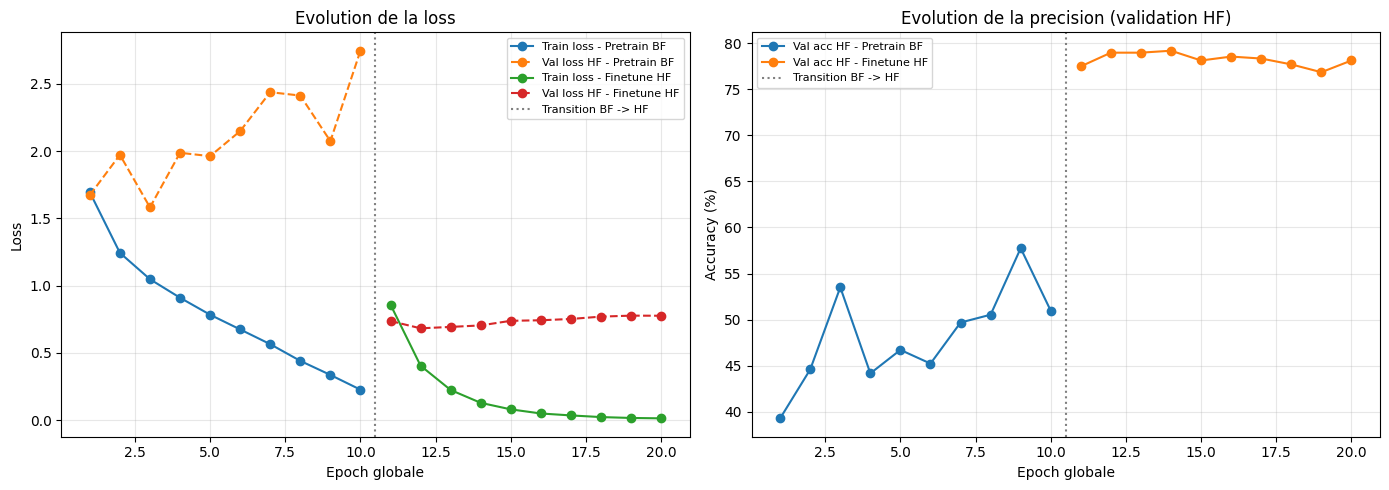

Figure sauvee: /content/drive/MyDrive/UTBM_PF22/results/strategy1_transfer_learning_curves.png


In [17]:
criterion = nn.CrossEntropyLoss()
test_hf_loss, test_hf_acc = evaluate(model, loader_test_hf, criterion)
test_bf_loss, test_bf_acc = evaluate(model, loader_test_bf, criterion)
test_mix_acc = (test_hf_acc + test_bf_acc) / 2.0

cost_pretrain = len(dataset_bf_train) * COST_BF * PRETRAIN_EPOCHS
cost_finetune = len(dataset_hf_train) * COST_HF * FINETUNE_EPOCHS
total_cost = cost_pretrain + cost_finetune
total_time_min = pretrain_time_min + finetune_time_min

results = {
    'strategy': 'transfer_learning_sequentiel',
    'pipeline': 'BF_pretraining_then_HF_finetuning',
    'pretrain_epochs': PRETRAIN_EPOCHS,
    'finetune_epochs': FINETUNE_EPOCHS,
    'lr_pretrain': LR_PRETRAIN,
    'lr_finetune': LR_FINETUNE,
    'cost_pretrain_CA': int(cost_pretrain),
    'cost_finetune_CA': int(cost_finetune),
    'total_cost_CA': int(total_cost),
    'pretrain_time_min': float(pretrain_time_min),
    'finetune_time_min': float(finetune_time_min),
    'total_time_min': float(total_time_min),
    'test_hf_loss': float(test_hf_loss),
    'test_bf_loss': float(test_bf_loss),
    'accuracy_HF': float(test_hf_acc),
    'accuracy_BF': float(test_bf_acc),
    'accuracy_Mixte': float(test_mix_acc)
}

json_path = os.path.join(RESULTS_DIR, 'results_strategy1_transfer_learning.json')
pth_path = os.path.join(RESULTS_DIR, 'model_strategy1_transfer_learning.pth')
png_path = os.path.join(RESULTS_DIR, 'strategy1_transfer_learning_curves.png')

with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

torch.save(model.state_dict(), pth_path)

print('--- RESULTATS FINAUX ---')
print(f"Test HF    : {test_hf_acc:.2f}%")
print(f"Test BF    : {test_bf_acc:.2f}%")
print(f"Test Mixte : {test_mix_acc:.2f}%")
print(f"Cout total : {total_cost} CA")
print(f"Temps total: {total_time_min:.2f} min")
print('JSON sauve:', json_path)
print('Model sauve:', pth_path)

x_pre = np.arange(1, PRETRAIN_EPOCHS + 1)
x_ft = np.arange(PRETRAIN_EPOCHS + 1, PRETRAIN_EPOCHS + FINETUNE_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x_pre, hist_pre['train_loss'], marker='o', label='Train loss - Pretrain BF')
axes[0].plot(x_pre, hist_pre['val_loss'], marker='o', linestyle='--', label='Val loss HF - Pretrain BF')
axes[0].plot(x_ft, hist_ft['train_loss'], marker='o', label='Train loss - Finetune HF')
axes[0].plot(x_ft, hist_ft['val_loss'], marker='o', linestyle='--', label='Val loss HF - Finetune HF')
axes[0].axvline(PRETRAIN_EPOCHS + 0.5, color='gray', linestyle=':', label='Transition BF -> HF')
axes[0].set_title('Evolution de la loss')
axes[0].set_xlabel('Epoch globale')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(x_pre, hist_pre['val_acc'], marker='o', label='Val acc HF - Pretrain BF')
axes[1].plot(x_ft, hist_ft['val_acc'], marker='o', label='Val acc HF - Finetune HF')
axes[1].axvline(PRETRAIN_EPOCHS + 0.5, color='gray', linestyle=':', label='Transition BF -> HF')
axes[1].set_title('Evolution de la precision (validation HF)')
axes[1].set_xlabel('Epoch globale')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(png_path, dpi=180, bbox_inches='tight')
plt.show()
print('Figure sauvee:', png_path)

## 6) Comparaison optionnelle avec les 3 baselines
Cette cellule charge les JSON existants s'ils sont disponibles dans RESULTS_DIR.

In [18]:
baseline_files = {
    'BL 1(HF)': 'results_baseline_HF.json',
    'BL 2(BF)': 'results_baseline_BF.json',
    'BL 3(MIXTE)': 'results_baseline_MIXTE.json',
    'Strategie 1(BF->HF)': 'results_strategy1_transfer_learning.json'
}

rows = []
for name, fn in baseline_files.items():
    p = os.path.join(RESULTS_DIR, fn)
    if os.path.exists(p):
        with open(p, 'r', encoding='utf-8') as f:
            d = json.load(f)
        rows.append((
            name,
            d.get('accuracy_HF', np.nan),
            d.get('accuracy_BF', np.nan),
            d.get('accuracy_Mixte', np.nan),
            d.get('total_cost_CA', np.nan),
            d.get('training_time_sec', np.nan) / 60.0 if 'training_time_sec' in d else d.get('total_time_min', np.nan)
        ))

if not rows:
    print('Aucun fichier JSON trouve pour la comparaison.')
else:
    header = f"{'Modele':<24} {'HF%':>8} {'BF%':>8} {'Mixte%':>10} {'Cout(CA)':>12} {'Temps(min)':>12}"
    print(header)
    print('-' * len(header))
    for r in rows:
        print(f"{r[0]:<24} {r[1]:>8.2f} {r[2]:>8.2f} {r[3]:>10.2f} {r[4]:>12.0f} {r[5]:>12.2f}")

Modele                        HF%      BF%     Mixte%     Cout(CA)   Temps(min)
-------------------------------------------------------------------------------
BL 1(HF)                    56.20    35.16      45.68       470400         2.84
BL 2(BF)                    59.07    63.66      61.36       424260        27.05
BL 3(MIXTE)                 75.90    65.03      70.47       894660        29.78
Strategie 1(BF->HF)         78.84    57.65      68.25       400230         7.83
